# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to understand the dataset by exploring its structure, identifying data quality issues, analyzing customer characteristics, and discovering patterns that influence customer churn.

The insights generated during EDA will guide feature engineering, model development, and business recommendations.

## Import Required Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

The customer churn dataset is loaded from the raw data directory for analysis.

In [3]:
# Load Dataset
df = pd.read_csv("../data/raw/European_Bank.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Display First Five Records

Understanding the structure and contents of the dataset before performing any preprocessing.

In [4]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Dataset Dimensions

Determine the number of rows and columns in the dataset.

In [5]:
print(f"Number of Rows : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows : 10000
Number of Columns : 14


## Dataset Information

Inspect data types and identify any missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


## Statistical Summary

Generate descriptive statistics for numerical features.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


# Data Quality Assessment

Before performing exploratory analysis, it is important to verify the quality of the dataset.

The following checks will be performed:

- Missing Values
- Duplicate Records
- Unique Values
- Invalid Data

In [8]:
# Missing Values

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_df

,Missing Values,Percentage
Year,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0


### Observation

No missing values are present in the dataset.

The dataset is complete and does not require imputation before machine learning.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


### Observation

The dataset contains no duplicate customer records.

Each row represents a unique customer profile.

In [10]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique_values

,Unique Values,Data Type
Year,1,int64
CustomerId,10000,int64
Surname,2932,str
CreditScore,460,int64
Geography,3,str
Gender,2,str
Age,70,int64
Tenure,11,int64
Balance,6382,float64
NumOfProducts,4,int64


### Business Insight

- CustomerId and Surname are customer identifiers and are unlikely to contribute to churn prediction.
- These features will be removed during preprocessing.
- Geography and Gender are categorical variables that require encoding before model training.

# Target Variable Analysis

## Business Question

What proportion of customers have churned?

Understanding the distribution of the target variable helps determine whether the dataset is balanced and provides an overview of customer churn.

In [11]:
# Count of Churned vs Retained Customers

df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
# Percentage of Churned vs Retained Customers

(df["Exited"].value_counts(normalize=True) * 100).round(2)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

## Visualization

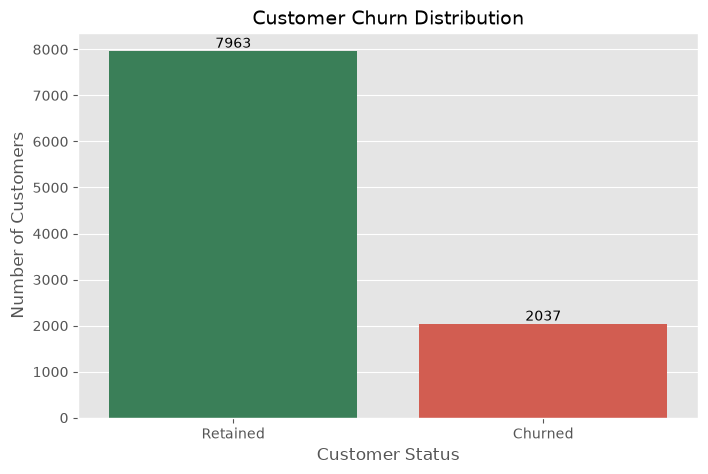

In [38]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Exited",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks([0,1], ["Retained", "Churned"])

# Display count on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.savefig(
    "../outputs/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

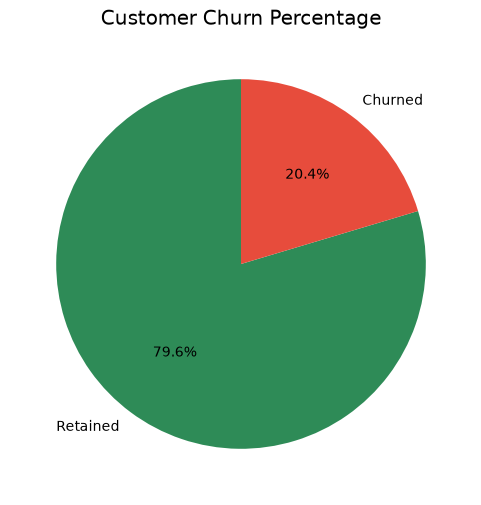

In [39]:
plt.figure(figsize=(6,6))

df["Exited"].value_counts().plot(
    kind="pie",
    labels=["Retained","Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E8B57","#E74C3C"]
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

# Save the figure
plt.savefig(
    "../outputs/churn_percentage_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- Most customers are retained by the bank.
- Approximately one-fifth of customers have churned.
- The dataset is moderately imbalanced, which should be considered during model training.

## Business Insight

Although the majority of customers remain with the bank, the churn rate is significant enough to impact revenue and customer acquisition costs. Predicting these customers before they leave can help improve retention and profitability.

## Recommendation

Develop a predictive machine learning model that identifies high-risk customers so that retention teams can proactively engage them with personalized offers and services.

# Univariate Analysis

## Business Question

How are customer characteristics distributed individually?

Understanding the distribution of each feature helps identify customer demographics, detect skewness, and discover potential patterns related to churn.

### Age Distribution

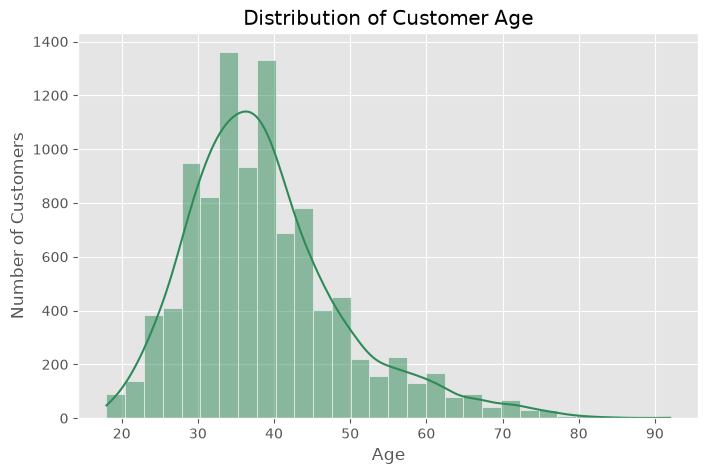

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True,
    color="#2E8B57"
)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Most customers are between 30 and 45 years old.
- The highest concentration of customers is around 35–40 years.
- The distribution is slightly right-skewed, with fewer customers above 60 years.

### Business Insight

The bank primarily serves middle-aged customers. Since customer age often influences financial behavior and product usage, age may play an important role in predicting customer churn.

## Credit Score Distribution

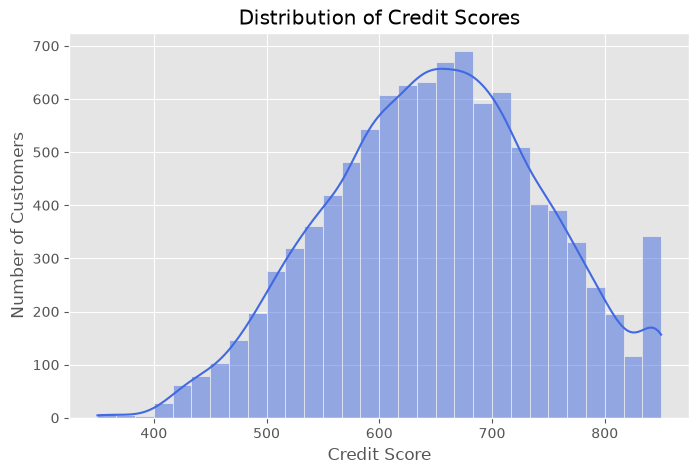

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="CreditScore",
    bins=30,
    kde=True,
    color="#4169E1"
)

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/credit_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Most customers have credit scores between 600 and 720.
- The distribution is approximately bell-shaped (close to normal).
- Very few customers have extremely low (<450) or extremely high (>800) credit scores.

### Business Insight

Most customers have average to good credit scores, indicating a relatively healthy customer base. Credit score is likely to be an important predictor of customer churn because it reflects a customer's financial reliability.

## Balance Distribution

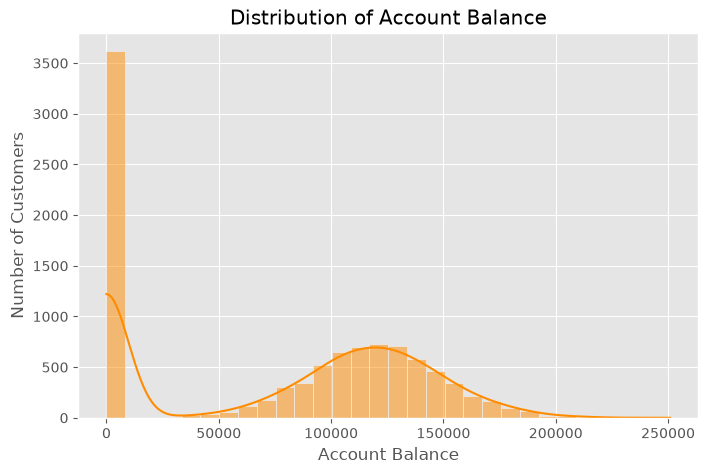

In [42]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Balance",
    bins=30,
    kde=True,
    color="#FF8C00"
)

plt.title("Distribution of Account Balance")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/balance_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- A large number of customers have a zero account balance.
- Customers with non-zero balances are mainly concentrated between 100,000 and 150,000.
- The distribution is bimodal, indicating two distinct groups of customers: those without deposits and those with significant account balances.

### Business Insight

The presence of many customers with zero balances suggests that not all customers actively use their bank accounts for savings or deposits. Account balance may be an important factor in customer churn and should be investigated further during bivariate analysis.

## Estimated Salary Distribution

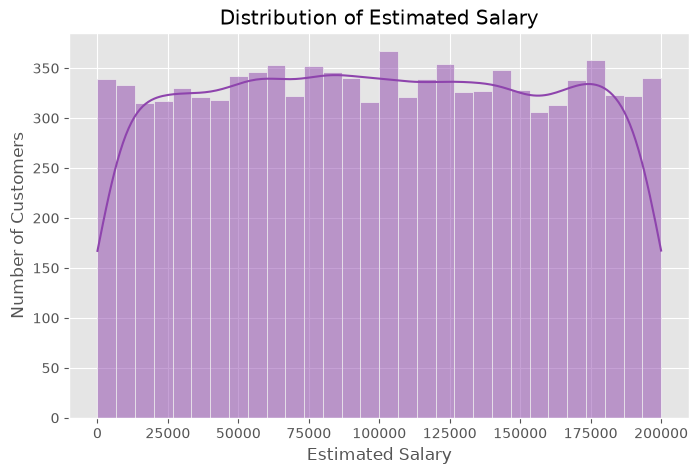

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="EstimatedSalary",
    bins=30,
    kde=True,
    color="#8E44AD"
)

plt.title("Distribution of Estimated Salary")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/estimated_salary_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Estimated salaries are evenly distributed across the entire salary range.
- No significant peaks or clusters are observed.
- Customer salaries range from approximately 0 to 200,000.

### Business Insight

Estimated salary appears to be uniformly distributed, suggesting that customers belong to diverse income groups. On its own, salary may not strongly explain customer churn and should be analyzed together with other customer attributes.

## Tenure Distribution

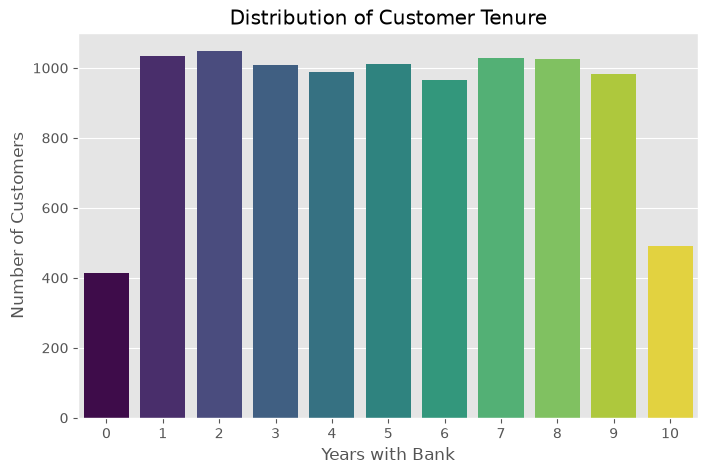

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Tenure",
    hue="Tenure",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Years with Bank")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/tenure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most tenure categories (1–9 years) have a similar number of customers.
- Customers with 0 years and 10 years of tenure are comparatively fewer.
- Overall, the tenure distribution is fairly uniform across the customer base.

### Business Insight

Customers are well distributed across different relationship durations with the bank. Since customers exist in both new and long-term segments, tenure may influence churn behavior and should be analyzed against the target variable.

## Number of Products Distribution

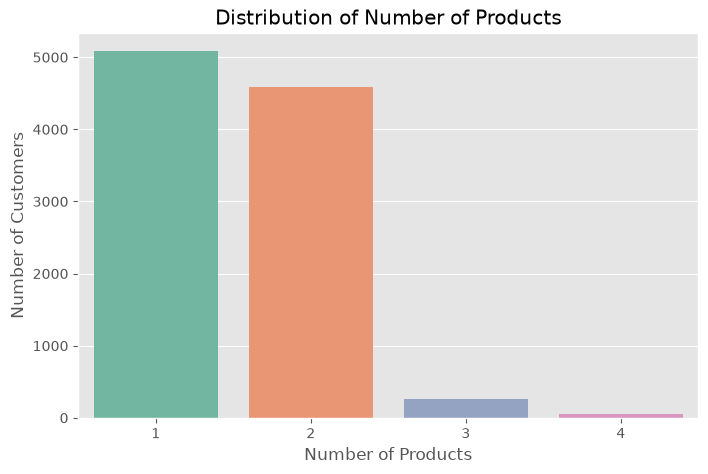

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="NumOfProducts",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/num_of_products_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most customers have either 1 or 2 banking products.
- Very few customers have 3 or 4 products.
- Customers with a single product slightly outnumber those with two products.

### Business Insight

The majority of customers use only one or two banking products, indicating opportunities for cross-selling additional services. Customers with more products may exhibit different loyalty and churn patterns, which should be explored in the bivariate analysis.

## Geography Distribution

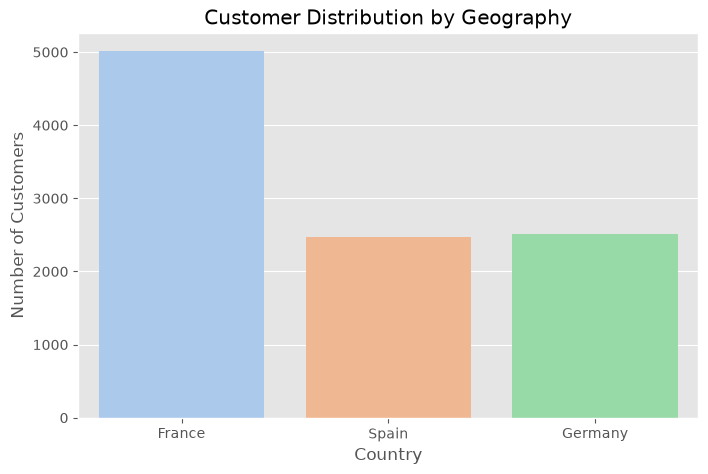

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Geography",
    hue="Geography",
    palette="pastel",
    legend=False
)

plt.title("Customer Distribution by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/geography_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- France has the largest number of customers in the dataset.
- Germany and Spain have nearly equal numbers of customers.
- Approximately half of all customers are from France.

### Business Insight

The customer base is concentrated in France, indicating it is the bank's primary market. Since customer behavior may differ across countries, geography could be an important feature for predicting customer churn and should be analyzed against the target variable.

## Gender Distribution

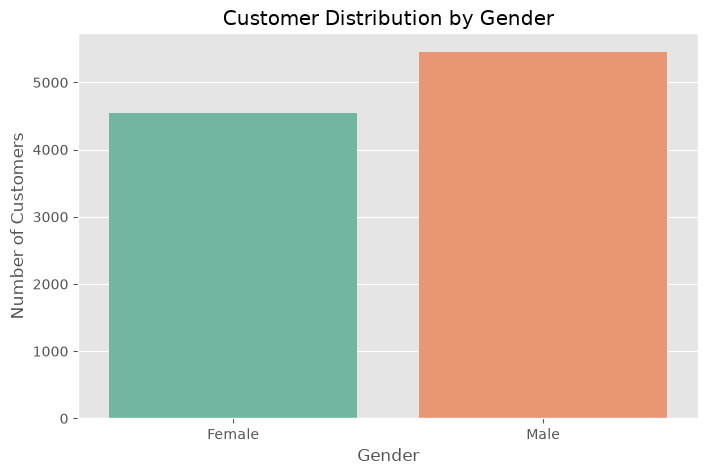

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.savefig(
    "../outputs/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The dataset contains slightly more male customers than female customers.
- The gender distribution is fairly balanced.
- There is no major gender imbalance in the customer base.

### Business Insight

Since both genders are well represented, gender may still influence customer churn. It should be analyzed further with the target variable (Exited) to determine whether one gender is more likely to leave the bank.

# Bivariate Analysis

## Business Question

Which customer characteristics are associated with customer churn?

Comparing each feature with the target variable (Exited) helps identify the factors that influence customer churn and provides valuable insights for predictive modeling.

## Age vs Churn

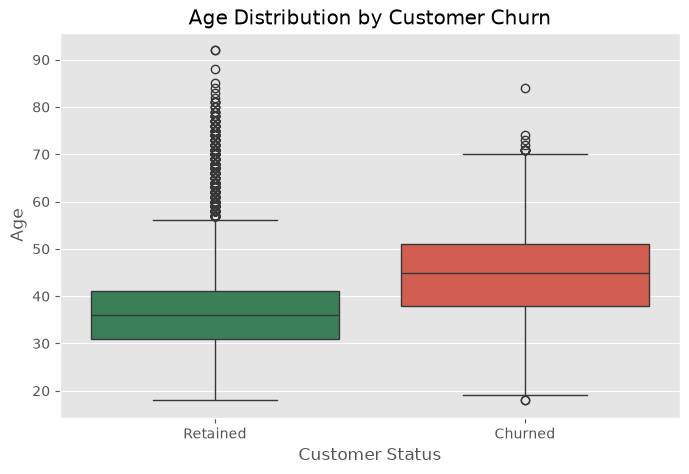

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Age",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.xticks([0,1], ["Retained","Churned"])
plt.title("Age Distribution by Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.savefig(
    "../outputs/age_distribution_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)
            
plt.show()

### Observation

- Customers who churned have a higher median age than customers who were retained.
- Most retained customers are between 30 and 40 years old.
- Churned customers are generally concentrated between 40 and 50 years old.
- Both groups contain a few older-age outliers.

### Business Insight

Age appears to have a strong relationship with customer churn. Older customers are more likely to leave the bank than younger customers, making age an important predictor for churn prediction models.

## Credit Score vs Churn

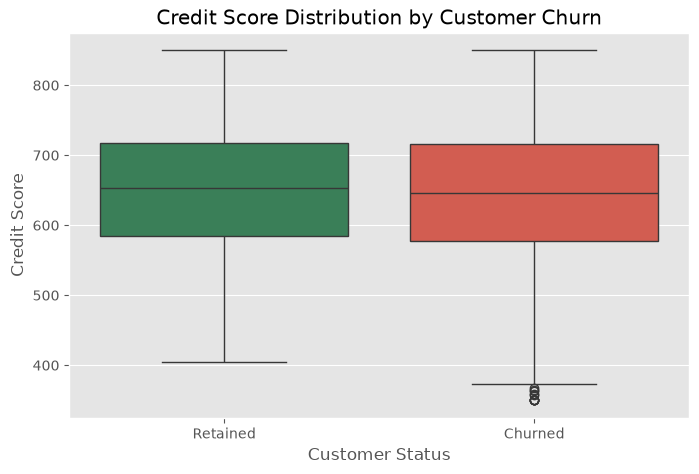

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.xticks([0,1], ["Retained", "Churned"])
plt.title("Credit Score Distribution by Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Credit Score")

plt.savefig(
    "../outputs/credit_score_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The median credit score is very similar for both retained and churned customers.
- The interquartile ranges (IQRs) of both groups largely overlap.
- Churned customers include a few customers with very low credit scores.
- Overall, there is no significant difference in credit score distribution between retained and churned customers.

### Business Insight

Credit score alone does not appear to strongly influence customer churn. While customers with lower credit scores may be slightly more likely to churn, this feature should be combined with other variables to improve churn prediction.

## Balance vs Churn

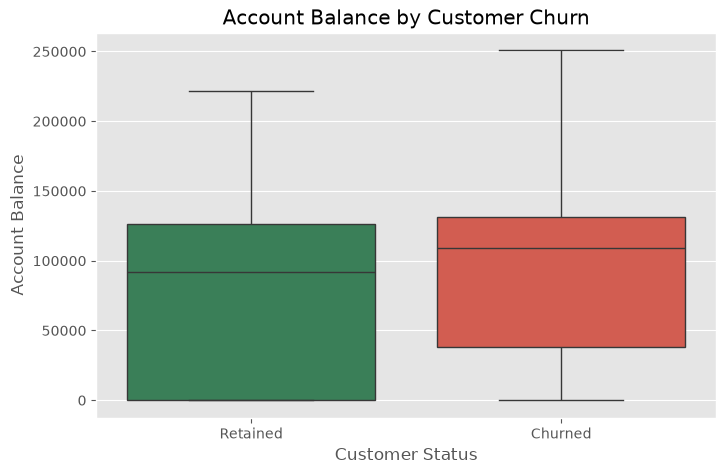

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.xticks([0,1], ["Retained", "Churned"])
plt.title("Account Balance by Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")

plt.savefig(
    "../outputs/balance_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Churned customers have a higher median account balance than retained customers.
- Retained customers include a large number of accounts with zero balance.
- Churned customers generally maintain higher account balances, with most balances concentrated above 100,000.
- The balance distribution for churned customers is shifted upward compared to retained customers.

### Business Insight

Account balance appears to be an important factor associated with customer churn. Customers with higher account balances are more likely to leave the bank, suggesting that retaining high-value customers should be a business priority through targeted engagement and loyalty programs.

## Estimated Salary vs Churn

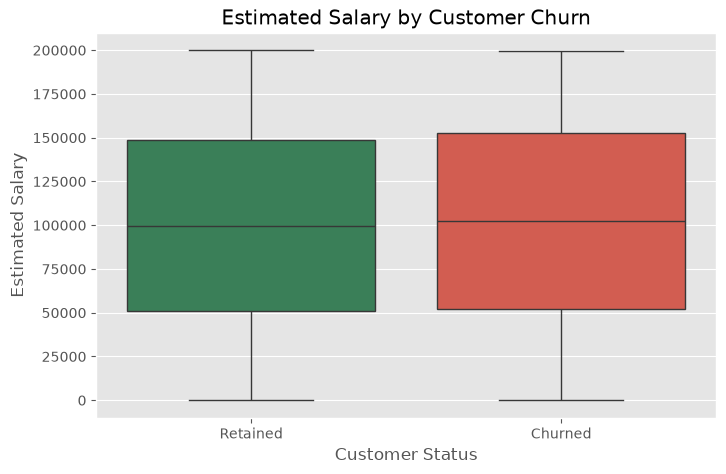

In [48]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="EstimatedSalary",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.xticks([0,1], ["Retained", "Churned"])
plt.title("Estimated Salary by Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Estimated Salary")

plt.savefig(
    "../outputs/estimated_salary_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The median estimated salary is almost identical for retained and churned customers.
- The interquartile ranges (IQRs) of both groups overlap significantly.
- Estimated salaries are distributed similarly across both customer groups.
- There is no noticeable difference in salary distribution between retained and churned customers.

### Business Insight

Estimated salary does not appear to have a strong relationship with customer churn. Income level alone is unlikely to explain why customers leave the bank and should be considered alongside other customer characteristics.

## Tenure vs Churn

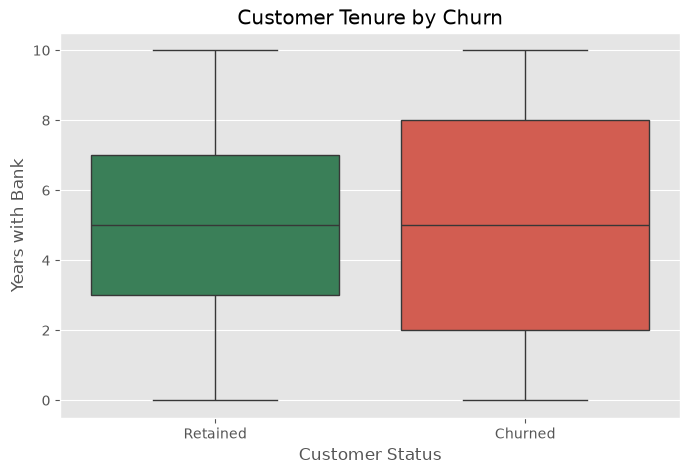

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Tenure",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"],
    legend=False
)

plt.xticks([0,1], ["Retained", "Churned"])
plt.title("Customer Tenure by Churn")
plt.xlabel("Customer Status")
plt.ylabel("Years with Bank")

plt.savefig(
    "../outputs/tenure_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- The median tenure is approximately the same for retained and churned customers.
- Both groups have customers across the full tenure range (0–10 years).
- Churned customers show slightly greater variation in tenure.
- Overall, tenure alone does not show a strong separation between retained and churned customers.

### Business Insight

Customer tenure appears to have only a weak relationship with churn. Since customers leave the bank across different tenure levels, retention strategies should focus on additional factors such as account activity, product usage, and customer engagement.

## Number of Products vs Customer Churn

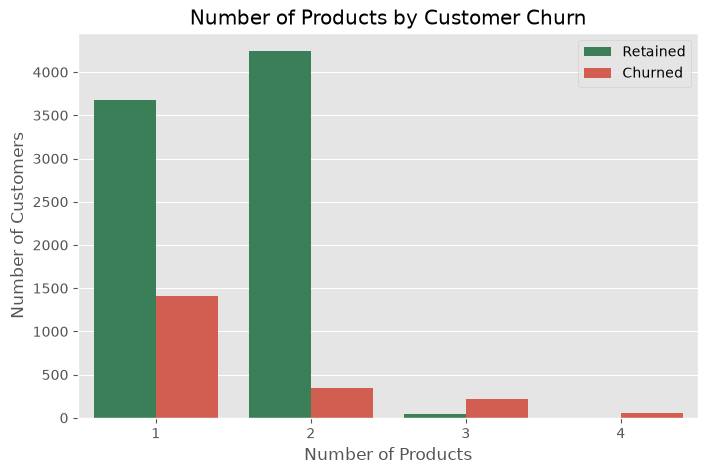

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="NumOfProducts",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"]
)

plt.title("Number of Products by Customer Churn")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.legend(["Retained", "Churned"])

plt.savefig(
    "../outputs/num_of_products_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most customers have either 1 or 2 banking products.
- Customers with 2 products show the highest retention rate.
- Customers with 3 or 4 products have a relatively higher proportion of churn despite their smaller population.
- Very few customers own more than 2 products.

### Business Insight

Customers with two products appear to be the most loyal, while those with three or more products exhibit a higher likelihood of churn. This suggests that product ownership may influence customer retention and should be explored further to understand why customers with multiple products are leaving.

## Geography vs Customer Churn

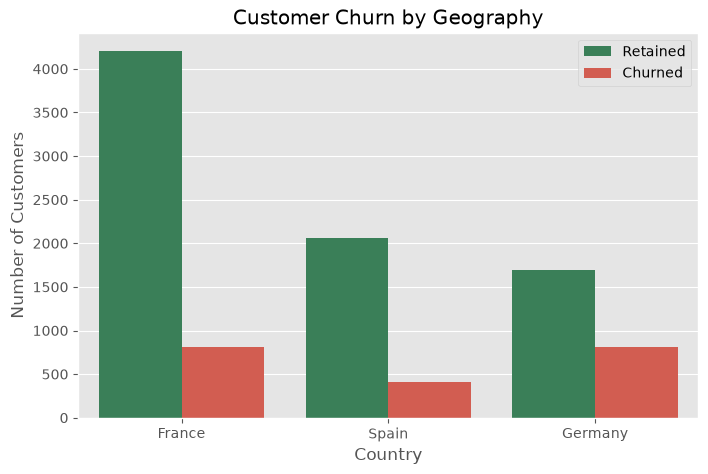

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Geography",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"]
)

plt.title("Customer Churn by Geography")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(["Retained", "Churned"])

plt.savefig(
    "../outputs/churn_by_geography.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- France has the largest number of customers, followed by Germany and Spain.
- Germany has a noticeably higher proportion of churned customers compared to the other countries.
- France has the highest number of retained customers.
- Spain shows the lowest customer count and a relatively lower churn level.

### Business Insight

Geography appears to influence customer churn. Customers in Germany exhibit a higher churn tendency, suggesting that regional factors such as customer preferences, competition, or service experience may affect retention. Country should be considered an important feature in churn prediction models.

## Gender vs Customer Churn

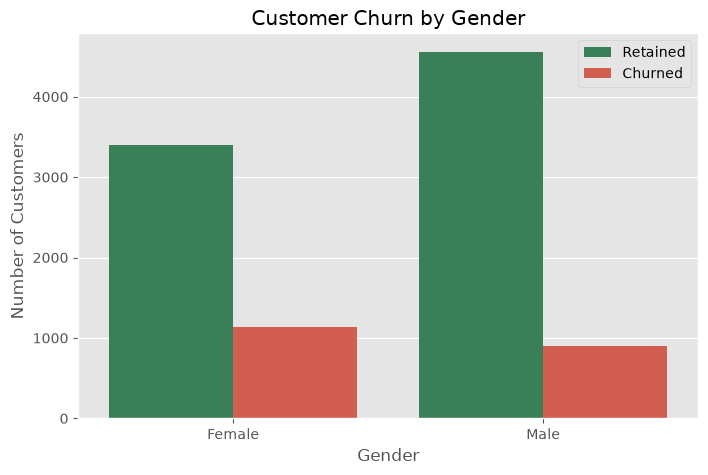

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Exited",
    palette=["#2E8B57", "#E74C3C"]
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(["Retained", "Churned"])

plt.savefig(
    "../outputs/gender_vs_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Male customers constitute a larger portion of the customer base.
- Female customers exhibit a higher proportion of churn compared to male customers.
- Male customers have a higher retention count.
- Gender appears to have an influence on customer churn behavior.

### Business Insight

Although the bank has more male customers overall, female customers appear to leave the bank more frequently. This suggests that customer retention strategies may need to consider gender-specific factors, making Gender a useful feature for churn prediction.

# Correlation Analysis

## Business Question

Which numerical features are most strongly associated with customer churn?

A correlation heatmap helps identify relationships among numerical variables and highlights features that may have predictive power for customer churn.

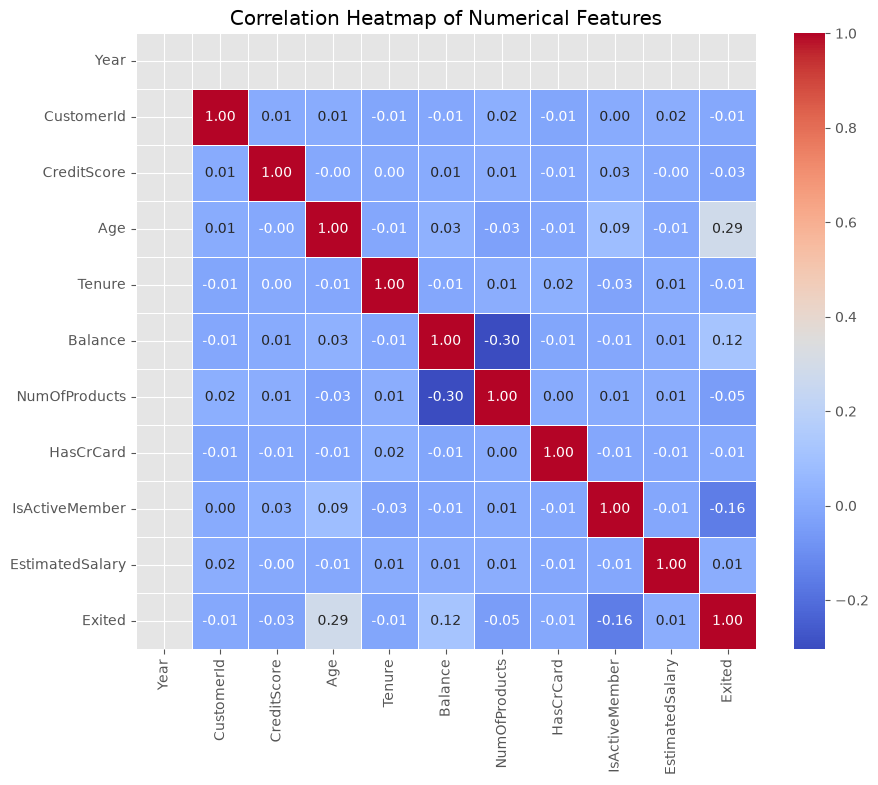

In [33]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.savefig(
    "../outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Observation

- Age has the strongest positive correlation with customer churn (0.29), indicating that older customers are more likely to leave the bank.
- IsActiveMember has a moderate negative correlation with churn (-0.16), suggesting active customers are less likely to churn.
- Balance shows a weak positive correlation with churn (0.12).
- Credit Score, Estimated Salary, Tenure, and HasCrCard have very weak correlations with churn.
- Balance and Number of Products exhibit a moderate negative correlation (-0.30), indicating customers with higher balances tend to hold fewer products.

### Business Insight

The correlation analysis indicates that Age and IsActiveMember are among the most informative numerical predictors of customer churn. While most individual features show weak linear relationships with churn, combining multiple customer attributes is likely to improve predictive performance. These findings support the use of machine learning models that can capture interactions between features rather than relying on single variables.

# Final EDA Summary

## Key Findings

- Customer churn is more common among older customers.
- Customers with lower activity levels are more likely to churn.
- Germany exhibits the highest churn rate among all regions.
- Female customers show a relatively higher churn tendency than male customers.
- Customers with two banking products demonstrate the highest retention, whereas those with three or more products are more likely to churn.
- Account balance shows a weak positive relationship with churn, while estimated salary has little influence.
- Credit score alone is not a strong indicator of churn.
- Most numerical variables have weak individual correlations with churn, suggesting that customer attrition is influenced by multiple interacting factors.

## Overall Conclusion

The exploratory data analysis reveals that customer churn is driven by a combination of demographic, behavioral, and financial factors rather than any single variable. Features such as Age, Geography, IsActiveMember, and Number of Products appear to have the greatest impact on customer retention. These insights provide a strong foundation for building predictive machine learning models that can accurately identify customers at risk of churn and support data-driven retention strategies.